# Routine Immunization — with vs. without

This notebook compares two otherwise-identical SIR-with-vital-dynamics simulations:

1. **No RI** — a baseline outbreak driven by births continually replenishing the susceptible pool, with monthly external importations seeding ongoing transmission.
2. **With RI** — the same model plus a `RoutineImmunization` component that periodically moves susceptibles into a `V` (vaccinated) compartment.

The point is to make the *demographic* effect of routine immunization visible: with RI in place, the steady stream of new susceptibles is intercepted before it can fuel the next epidemic wave.  Without RI, monthly importations repeatedly ignite into full outbreaks every few years; with RI, importations fade harmlessly.

## How `RoutineImmunization` works

Given an annual coverage rate $r$ and an eligible-fraction $ef$ (the share of $S$ that is age-eligible — typically infants), the daily fraction of susceptibles vaccinated is

$$
f_\text{daily} = \frac{r \, ef}{365}
$$

When the component fires every $p$ ticks instead of every tick (cheaper, and a closer match to real monthly RI schedules), each firing must cover the cohort accumulated over the preceding $p$ days:

$$
f_\text{period} = \frac{p \, r \, ef}{365}.
$$

On each firing tick the per-node count is drawn as $\min\bigl(\mathrm{Poisson}(f_\text{period} \cdot S),\; S\bigr)$ and moved from `S` to `V`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from laser.core import PropertySet
from laser.core.utils import grid
from laser.generic.utils import ValuesMap

from laser.cohorts import Model, RoutineImmunization, Campaign, Intervention
from laser.cohorts.vitaldynamics import NonDiseaseMortality, ConstantPopBirths
import laser.cohorts.SIR as SIR


class Importation(Intervention):
    """Inject `count` infectious individuals into the targeted nodes on this tick."""

    @property
    def states(self):
        return []

    @property
    def properties(self):
        return []

    def apply(self, tick, who, where, params, notes):
        count = int(params.get("count", 1))
        target = where if where is not None else list(range(len(self.model.scenario)))
        I_idx = self.model.states.get_state_index("I")
        for node in target:
            self.model.states[tick + 1][I_idx, node] += count


Campaign.register(Importation)
print("Registered Importation intervention")

Registered Importation intervention


## Shared simulation parameters

A single-node, 500,000-person population with $R_0 \approx 4$, an 8-day infectious period, a 15-year life expectancy (high birth rate, so the susceptible pool refills quickly), and 30% seasonal forcing in transmission.  Monthly importation of 2 cases ensures the chain of transmission can restart after each wave fades.  Twenty years is enough to see multiple boom-and-bust cycles in the no-RI scenario, and to watch RI suppress everything after the first wave in the RI scenario.

In [2]:
nticks   = 20 * 365
n_nodes  = 1
N0       = 500_000
I0       = 100

R0_basic = 4.0
gamma    = 1.0 / 8.0
beta_val = R0_basic * gamma
life_yrs = 15.0
r_mort   = 1.0 / (life_yrs * 365.0)

epsilon  = 0.3                                  # seasonal amplitude
t_ticks  = np.arange(nticks)
seasonal = 1.0 + epsilon * np.cos(2.0 * np.pi * (t_ticks - 15) / 365.0)
seasonality_2d = np.tile(seasonal[:, None], (1, n_nodes))

import_period = 30
import_when   = list(range(0, nticks, import_period))
import_schedule = [
    {"who": "*", "what": "Importation", "when": import_when, "where": "*",
     "parameters": {"count": 2}, "notes": "monthly external seeding"},
]

S0 = N0 - I0
print(f"Initial S={S0:,}  I={I0}  N={N0:,}")
print(f"beta={beta_val:.4f}  gamma={gamma:.4f}  r_mortality={r_mort:.2e}")
print(f"Seasonal factor range: {seasonal.min():.2f} – {seasonal.max():.2f}")
print(f"Importation events: {len(import_when)} over {nticks} ticks")

Initial S=499,900  I=100  N=500,000
beta=0.5000  gamma=0.1250  r_mortality=1.83e-04
Seasonal factor range: 0.70 – 1.30
Importation events: 244 over 7300 ticks


In [3]:
def build_model(*, with_ri: bool, seed: int = 42) -> Model:
    """Build the shared SIR + vital-dynamics + seasonal-importation model, optionally adding RI."""
    np.random.seed(seed)

    scenario = grid(M=n_nodes, N=1)
    scenario["S"] = S0
    scenario["I"] = I0
    scenario["R"] = 0

    params = PropertySet({"nticks": nticks})
    model = Model(scenario, params)

    betas        = ValuesMap.from_scalar(beta_val, nticks, n_nodes)
    r_recoveries = ValuesMap.from_scalar(gamma,    nticks, n_nodes)
    campaign     = Campaign(model, import_schedule)

    components = [
        SIR.Susceptible(model),
        SIR.Infectious(model, r_recovery=r_recoveries),
        SIR.Recovered(model),
        SIR.Transmission(model, beta=betas, seasonality=seasonality_2d),
        NonDiseaseMortality(model, r_mortality=r_mort),
        ConstantPopBirths(model),
        campaign,
    ]
    if with_ri:
        # 50% annual coverage of the susceptible pool, applied every 30 days.
        # eligible_fraction=1.0 is the simplest demonstration; for an age-structured
        # programme you would scale ef to the eligible cohort (e.g. ef = 1/life_yrs
        # for an infant-only RI).
        components.append(
            RoutineImmunization(
                model,
                coverage=0.5,
                eligible_fraction=1.0,
                period=30,
            )
        )

    model.components = components
    return model


model_no_ri   = build_model(with_ri=False)
model_with_ri = build_model(with_ri=True)

model_no_ri.run()
model_with_ri.run()

print(f"Cumulative new infections — no RI    = {int(model_no_ri.nodes.newly_infectious.sum()):>10,}")
print(f"Cumulative new infections — with RI  = {int(model_with_ri.nodes.newly_infectious.sum()):>10,}")
print(f"Final V (with RI)                    = {int(model_with_ri.states.V[-1, 0]):>10,}")
print(f"Total RI vaccinations                = {int(model_with_ri.nodes.ri_vaccinated.sum()):>10,}")

Cumulative new infections — no RI    =    860,328
Cumulative new infections — with RI  =    475,270
Final V (with RI)                    =    316,786
Total RI vaccinations                =    561,843


## Side-by-side trajectories

Three panels:

1. **Susceptibles $S(t)$** — without RI, $S$ refills via births and oscillates around the endemic equilibrium $S^*/N = 1/R_0$ (dashed line).  With RI, $S$ is held well below the equilibrium because newly born susceptibles are intercepted before they accumulate.
2. **Infectious $I(t)$** — without RI, the model shows recurrent epidemic peaks.  With RI, transmission collapses after the initial wave because $S$ never recovers to a level that supports $R_\text{eff} > 1$.
3. **Vaccinated $V(t)$ vs cumulative new infections** — with RI the vaccinated pool grows steadily; without RI it stays at zero (the V compartment doesn't exist).  The cumulative cases curve shows how the two outbreaks diverge.

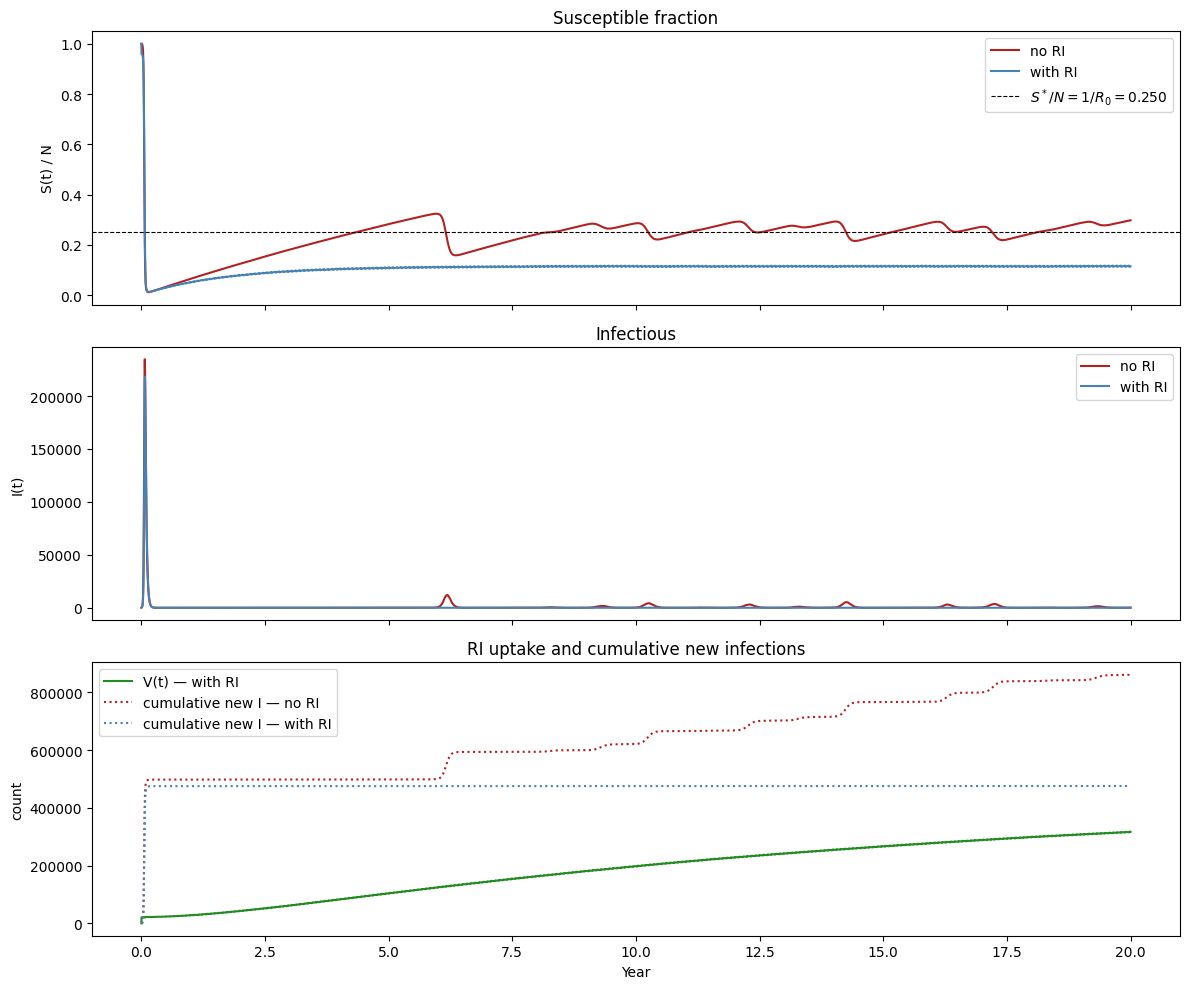

In [4]:
t_years = np.arange(nticks + 1) / 365.0

S_no  = model_no_ri.states.S[:, 0]
I_no  = model_no_ri.states.I[:, 0]
S_ri  = model_with_ri.states.S[:, 0]
I_ri  = model_with_ri.states.I[:, 0]
V_ri  = model_with_ri.states.V[:, 0]

# Cumulative new infections per scenario
new_no = model_no_ri.nodes.newly_infectious[:, 0]
new_ri = model_with_ri.nodes.newly_infectious[:, 0]
cum_no = np.cumsum(new_no)
cum_ri = np.cumsum(new_ri)
t_inc  = np.arange(nticks) / 365.0

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

axes[0].plot(t_years, S_no / N0, color="firebrick",  label="no RI")
axes[0].plot(t_years, S_ri / N0, color="steelblue",  label="with RI")
axes[0].axhline(1.0 / R0_basic, color="black", linestyle="--", linewidth=0.8,
                label=fr"$S^*/N = 1/R_0 = {1.0/R0_basic:.3f}$")
axes[0].set_ylabel("S(t) / N")
axes[0].set_title("Susceptible fraction")
axes[0].legend()

axes[1].plot(t_years, I_no, color="firebrick", label="no RI")
axes[1].plot(t_years, I_ri, color="steelblue", label="with RI")
axes[1].set_ylabel("I(t)")
axes[1].set_title("Infectious")
axes[1].legend()

axes[2].plot(t_years, V_ri, color="forestgreen", label="V(t) — with RI")
axes[2].plot(t_inc,   cum_no, color="firebrick", linestyle=":",  label="cumulative new I — no RI")
axes[2].plot(t_inc,   cum_ri, color="steelblue", linestyle=":",  label="cumulative new I — with RI")
axes[2].set_ylabel("count")
axes[2].set_xlabel("Year")
axes[2].set_title("RI uptake and cumulative new infections")
axes[2].legend()

plt.tight_layout()
plt.show()

## Annual incidence comparison

Binning new infections by calendar year makes the long-run effect of RI obvious: total cases per year fall by an order of magnitude or more once RI is in place.

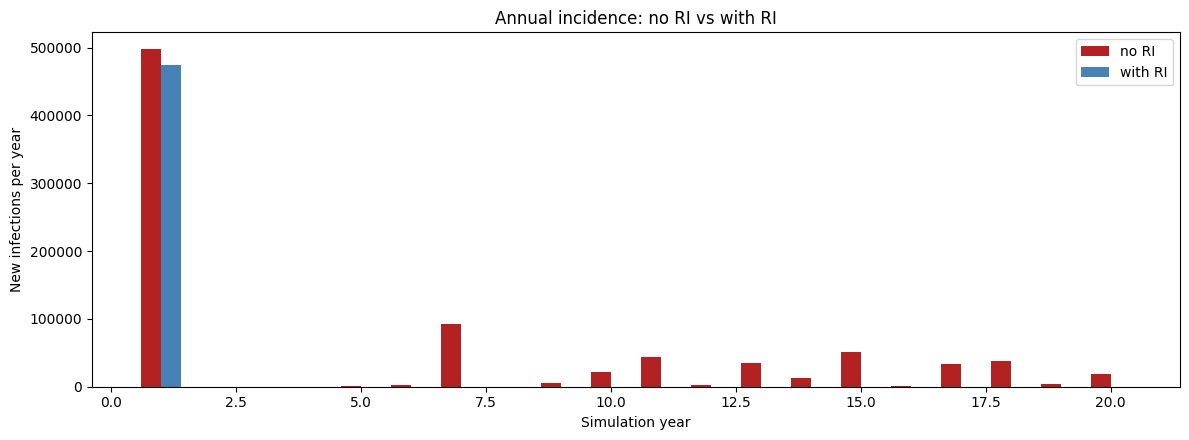

Year |  cases (no RI)  |  cases (RI)  |  vaccinations (RI)
-----+-----------------+--------------+--------------------
   1 |         497,524 |      474,889 |             29,809
   2 |              10 |           17 |             17,067
   3 |              37 |           11 |             22,148
   4 |              58 |            7 |             25,437
   5 |             425 |           17 |             26,913
   6 |           2,464 |           10 |             27,852
   7 |          92,871 |           14 |             30,886
   8 |             315 |           19 |             28,595
   9 |           5,664 |           14 |             28,940
  10 |          21,623 |           21 |             28,827
  11 |          44,443 |           44 |             29,209
  12 |           2,258 |           23 |             28,938
  13 |          34,239 |           14 |             31,178
  14 |          13,506 |           20 |             29,002
  15 |          50,586 |           13 |             28,

ERROR:tornado.general:Uncaught exception in ZMQStream callback
Traceback (most recent call last):
  File "/Users/christopherlorton/projects/laser-fresh/laser.cohorts/.venv/lib/python3.12/site-packages/zmq/eventloop/zmqstream.py", line 565, in _log_error
    f.result()
  File "/Users/christopherlorton/projects/laser-fresh/laser.cohorts/.venv/lib/python3.12/site-packages/ipykernel/kernelbase.py", line 584, in shell_channel_thread_main
    _, msg2 = self.session.feed_identities(msg, copy=False)
              ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/christopherlorton/projects/laser-fresh/laser.cohorts/.venv/lib/python3.12/site-packages/jupyter_client/session.py", line 998, in feed_identities
    raise ValueError(msg)
ValueError: DELIM not in msg_list
ERROR:tornado.general:Uncaught exception in ZMQStream callback
Traceback (most recent call last):
  File "/Users/christopherlorton/projects/laser-fresh/laser.cohorts/.venv/lib/python3.12/site-packages/zmq/eventloop/zmqstrea

In [5]:
n_years = nticks // 365
annual_no = new_no[: n_years * 365].reshape(n_years, 365).sum(axis=1)
annual_ri = new_ri[: n_years * 365].reshape(n_years, 365).sum(axis=1)
annual_vacc = (
    model_with_ri.nodes.ri_vaccinated[: n_years * 365, 0].reshape(n_years, 365).sum(axis=1)
)
years = np.arange(n_years) + 1

fig, ax = plt.subplots(figsize=(12, 4.5))
width = 0.4
ax.bar(years - width / 2, annual_no, width=width, color="firebrick",  label="no RI")
ax.bar(years + width / 2, annual_ri, width=width, color="steelblue",  label="with RI")
ax.set_xlabel("Simulation year")
ax.set_ylabel("New infections per year")
ax.set_title("Annual incidence: no RI vs with RI")
ax.legend()
plt.tight_layout()
plt.show()

print("Year |  cases (no RI)  |  cases (RI)  |  vaccinations (RI)")
print("-----+-----------------+--------------+--------------------")
for yr, c_no, c_ri, v_ri in zip(years, annual_no, annual_ri, annual_vacc):
    print(f" {yr:>3d} | {int(c_no):>15,} | {int(c_ri):>12,} | {int(v_ri):>18,}")

## What to take away

- **Without RI** the model produces the classic boom-and-bust pattern: after the first wave consumes most susceptibles, births refill `S` over a few years and a subsequent importation reignites a second (then third, etc.) outbreak.  The annual incidence bar chart makes the cycle obvious.
- **With RI** the susceptible pool is held permanently below the reinfection threshold $1/R_0$.  Monthly importations still occur, but each one dies out within days because $R_\text{eff} < 1$ — RI converts a transmissible system into a non-transmissible one.
- The total `V` count grows roughly linearly at $r \cdot ef \cdot S$ vaccinations per year (here ≈ 50% of `S` annually).  Once `S` stabilises at a low level, new vaccinations effectively balance new births.

### Things to try

- Drop `coverage` from `0.5` to `0.2` — RI is insufficient, outbreaks return at reduced amplitude.
- Set `eligible_fraction = 1/15` (infant-only with 15-year life expectancy) — RI matches birth rate exactly at 100% coverage; below that, outbreaks creep back.
- Increase `period` from `30` to `180` — the per-firing fraction grows by 6× to compensate, and the long-run mean remains the same; individual firings vaccinate more people at once.
- Reduce the importation `count` to 1 every 90 days — even without RI, importations are sparse enough that occasional outbreaks die out without sparking a wave.